# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [37]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

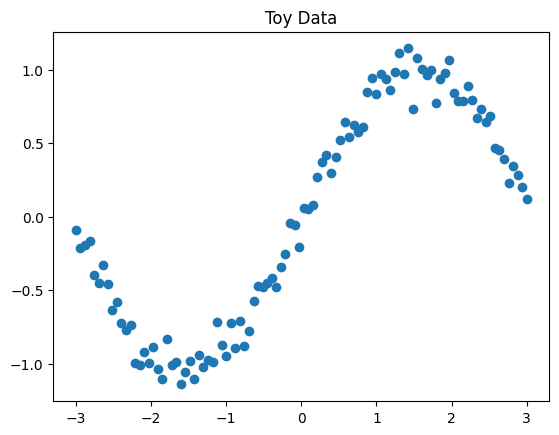

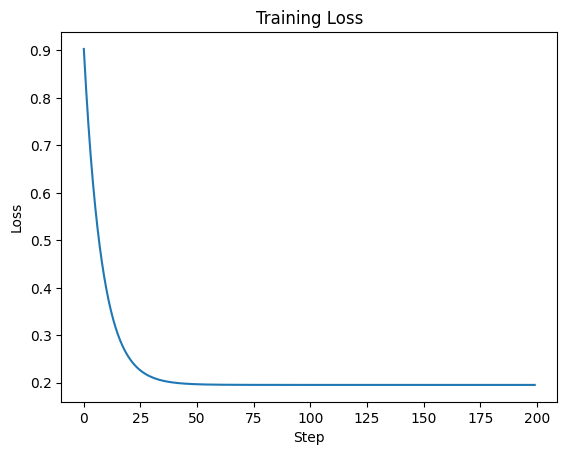

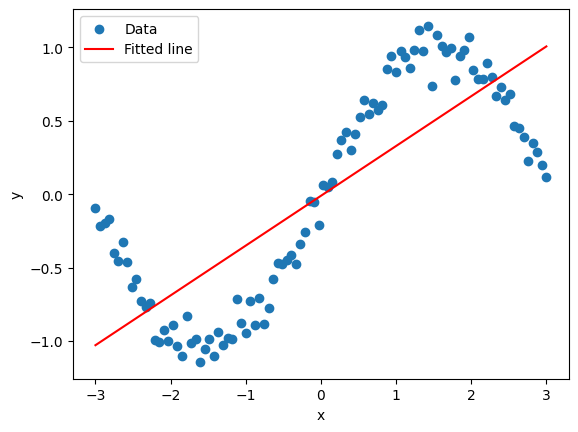

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

# Removed plt.plot(x) and plt.plot(y) to clean up the graph
plt.scatter(x, y)
plt.title("Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
# Replaced random.randint with small normal distribution values
w = np.random.randn() * 0.1 
b = np.random.randn() * 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps
lr = 0.01
losses = []
for step in range(200):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2) 
    dw    = np.mean(2 * (y_hat - y) * x) 
    db    = np.mean(2 * (y_hat - y)) 
    w    -= lr * dw
    b    -= lr * db
    losses.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# TODO: Plot (b) the data with the fitted line on top.
plt.scatter(x, y, label="Data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [Double-click to edit]
Question 2
This is  underfitting. A single neuron computes a simple linear function  which can only ever produce a straight line. Because a sine wave is non-linear and periodic, a straight line lacks the capacity/expressiveness to fit the curve, regardless of how long it is trained.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

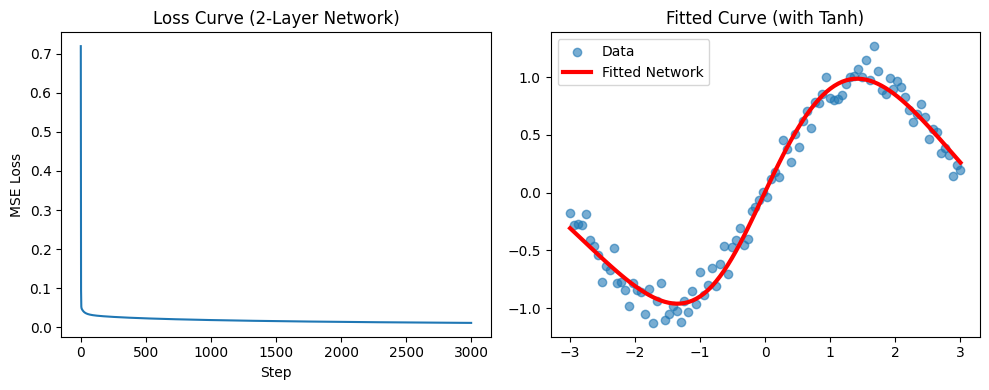

In [39]:
# TODO: Initialise parameters

x = np.linspace(-3,3,100).reshape(-1,1)
noise = np.random.normal(0,0.1,(100,1))
y = np.sin(x)+noise
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.05  # Learning rate
losses = []

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
for i in range(3000):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(10, 4))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss Curve (2-Layer Network)")
plt.xlabel("Step")
plt.ylabel("MSE Loss")

# Final Fit
plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.6, label="Data")
plt.plot(x, y_hat, color='red', linewidth=3, label="Fitted Network")
plt.title("Fitted Curve (with Tanh)")
plt.legend()

plt.tight_layout()
plt.show()



**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*

Stacking linear steps without activation functions just combines them into one big linear step. Mathematically,y_hat = (x * W1 + b1) * W2 + b2 = x * (W1 * W2) + (b1 * W2 + b2)

*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
Each hidden neuron creates a smooth S-shaped curve using tanh. The output layer joins these 8 different curves together to build the smooth wave shape.

*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*
Backpropagation works backward from the final error to calculate how much each weight contributed to the mistake using the chain rule.

> **Answer:** [Double-click to edit]



### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/var/folders/cc/mp95hkkn0txd_9bdxgb1h9gm0000gn/T/ipykernel_2718/4283911468.py:28: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/var/folders/cc/mp95hkkn0txd_9bdxgb1h9gm0000gn/T/ipykernel_2718/4283911468.py:36: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)  # Reusing h instead of calling tanh again


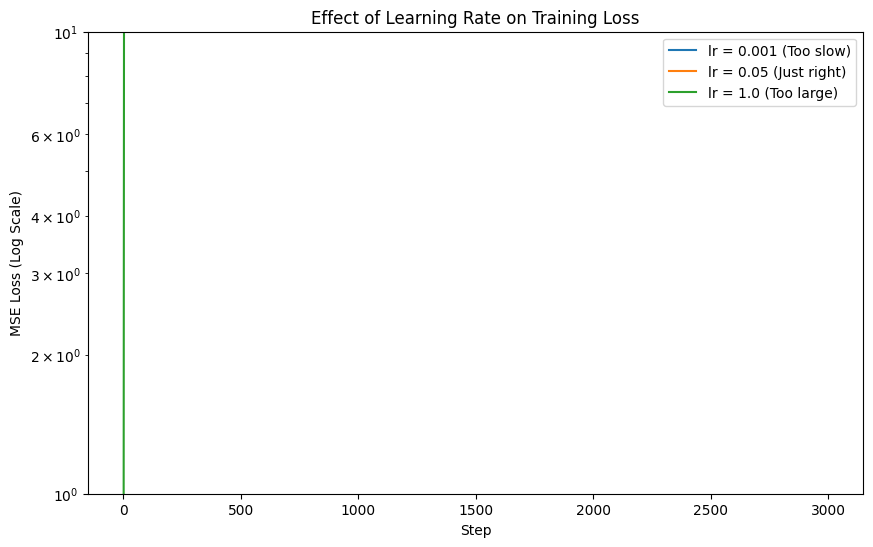

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def train_toy(lr, steps=3000):
    # Reset the seed so initial weights and noise are identical for each run
    np.random.seed(42)
    
    # 1. Generate the toy data
    x = np.linspace(-3, 3, 100).reshape(-1, 1)
    noise = np.random.normal(0, 0.1, (100, 1))
    y = np.sin(x) + noise
    
    # 2. Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)  # Initialize biases to zero for better convergence
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)  # Initialize biases to zero for better convergence
    
    losses = []
    
    # 3. Training loop
    for i in range(steps):
        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)
        
        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)  # Reusing h instead of calling tanh again
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)
        
        # Parameter updates
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        
    return losses

# Run with three learning rates (same initial weights each time, thanks to the seed reset)
losses_small = train_toy(lr=0.001)
losses_medium = train_toy(lr=0.05)
losses_large = train_toy(lr=1.0)

plt.figure(figsize=(10, 6))
plt.plot(losses_small, label="lr = 0.001 ")
plt.plot(losses_medium, label="lr = 0.05 ")
plt.plot(losses_large, label="lr = 1.0 ")

plt.yscale('log')
  # <-- caps the y-axis so the lr=1.0 blowup doesn't crush the other two lines
plt.title("Effect of Learning Rate on Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE Loss (Log Scale)")
plt.legend()

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]
lr = 0.001 (Too small): The model learns slowly and takes too long to reach the best fit.
lr = 0.05 (Good): The loss drops smoothly and quickly to a good solution.
lr = 1.0 (Too big): The loss jumps around wildly or explodes because the steps are too drastic.


When the learning rate is too large, the weight updates overshoot the best spot and land on a steeper part of the curve, causing even bigger jumps on the next step.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [3]:
import ssl
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Setup Constants and Fix SSL
RANDOM_STATE = 42
ssl._create_default_https_context = ssl._create_unverified_context

# 2. Load the dataset[cite: 1]
url = "https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/refs/heads/main/Lab2/Obesity_level_prediction_dataset%20(2).csv"
obesity = pd.read_csv(url)

# 3. Encode Categoricals[cite: 1]
# Note: Added .astype(str).str.strip() to strip hidden spaces from the CSV strings
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].astype(str).str.strip().map({"yes": 1, "no": 0})

obesity["Gender"] = obesity["Gender"].astype(str).str.strip().map({
    "Female": 0, 
    "Male": 1
})

freq_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity["CAEC"] = obesity["CAEC"].astype(str).str.strip().map(freq_order)
obesity["CALC"] = obesity["CALC"].astype(str).str.strip().map(freq_order)

mtrans_order = {
    "Walking": 0, 
    "Bike": 1, 
    "Public_Transportation": 2, 
    "Automobile": 3, 
    "Motorbike": 4
}
obesity["MTRANS"] = obesity["MTRANS"].astype(str).str.strip().map(mtrans_order)

# Fallback: fill any mapping mismatches (NaNs) with 0 to prevent the scaler from crashing
obesity = obesity.fillna(0)

# Encode the target NObeyesdad into integers 0..6[cite: 1]
label_encoder = LabelEncoder()
obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])

# 4. Stratified train / validation / test split (60/20/20)[cite: 1]
X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# 5. Fit a StandardScaler on the TRAINING set only[cite: 1]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_val_scaled   = scaler.transform(X_val)         
X_test_scaled  = scaler.transform(X_test)        

# 6. Convert to tensors and wrap in DataLoaders[cite: 1]
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val.values, dtype=torch.long)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print(obesity.head())
print(X_train.shape, X_val.shape, X_test.shape)

print("Success: Data loaded, encoded, scaled, and split into DataLoaders!")

   Gender   Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  \
0       0  21.0    1.62    64.0                               1     0   2.0   
1       0  21.0    1.52    56.0                               1     0   3.0   
2       1  23.0    1.80    77.0                               1     0   2.0   
3       1  27.0    1.80    87.0                               0     0   3.0   
4       1  22.0    1.78    89.8                               0     0   2.0   

   NCP  CAEC  SMOKE  CH2O  SCC  FAF  TUE  CALC  MTRANS  NObeyesdad  
0  3.0     1      0   2.0    0  0.0  1.0     0       2           1  
1  3.0     1      1   3.0    1  3.0  0.0     1       2           1  
2  3.0     1      0   2.0    0  2.0  1.0     2       2           1  
3  3.0     1      0   2.0    0  2.0  0.0     2       0           5  
4  1.0     1      0   2.0    0  0.0  0.0     1       2           6  
(1266, 16) (422, 16) (423, 16)
Success: Data loaded, encoded, scaled, and split into DataLoaders!


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
PyTorch's loss function automatically handles log-softmax internally, so it requires single integer class labels (0,1,2...) instead of one-hot encoded lists.

*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks careso much? Connect your answer to the gradient formulas you wrote in Section 1.*

Neural network updates depend directly on input feature sizes. Unscaled features cause gradients to update unevenly and ruin training. Random forests compare features one by one, so scale doesn't affect them.

*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*
Shuffling randomizes the order of data in each batch so the model doesn't memorize the sequence and learns better general patterns.
> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [7]:
import torch
import torch.nn as nn

# Ensure DEVICE is defined safely
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], n_classes)   
        )

    def forward(self, x):
        return self.net(x)

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train.shape[1]  

model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)
model = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

first_layer_params = input_dim * 64 + 64   # weights + biases
print(f"First layer (by hand): {first_layer_params}")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3399
First layer (by hand): 1088


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*

Layer 1: (16 inputs×64 neurons)+64 biases=1,088
Layer 2: (64 inputs×32 neurons)+32 biases=2,080
Output Layer: (32 inputs×7 classes)+7 biases=231
Total: 1,088+2,080+231=3,399 parameters

*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
ReLU doesn't suffer from vanishing gradients on large numbers like tanh does, and it is faster for the computer to calculate.

*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*
The network would collapse into a flat linear model that can only draw straight decision boundaries

> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.8344 | Train Acc: 0.2670 | Val Loss: 1.7006 | Val Acc: 0.3863
Epoch 02/50 | Train Loss: 1.5155 | Train Acc: 0.4652 | Val Loss: 1.3363 | Val Acc: 0.5308
Epoch 03/50 | Train Loss: 1.1790 | Train Acc: 0.5940 | Val Loss: 1.0727 | Val Acc: 0.6066
Epoch 04/50 | Train Loss: 0.9483 | Train Acc: 0.6651 | Val Loss: 0.9029 | Val Acc: 0.6564
Epoch 05/50 | Train Loss: 0.7931 | Train Acc: 0.7212 | Val Loss: 0.7891 | Val Acc: 0.7251
Epoch 06/50 | Train Loss: 0.6723 | Train Acc: 0.7828 | Val Loss: 0.6965 | Val Acc: 0.7559
Epoch 07/50 | Train Loss: 0.5824 | Train Acc: 0.8025 | Val Loss: 0.6250 | Val Acc: 0.7844
Epoch 08/50 | Train Loss: 0.5077 | Train Acc: 0.8341 | Val Loss: 0.5684 | Val Acc: 0.7986
Epoch 09/50 | Train Loss: 0.4446 | Train Acc: 0.8602 | Val Loss: 0.5179 | Val Acc: 0.8412
Epoch 10/50 | Train Loss: 0.3936 | Train Acc: 0.8870 | Val Loss: 0.4782 | Val Acc: 0.8483
Epoch 11/50 | Train Loss: 0.3482 | Train Acc: 0.8957 | Val Loss: 0.4503 | Val Acc: 0.8578
Epoch 12/5

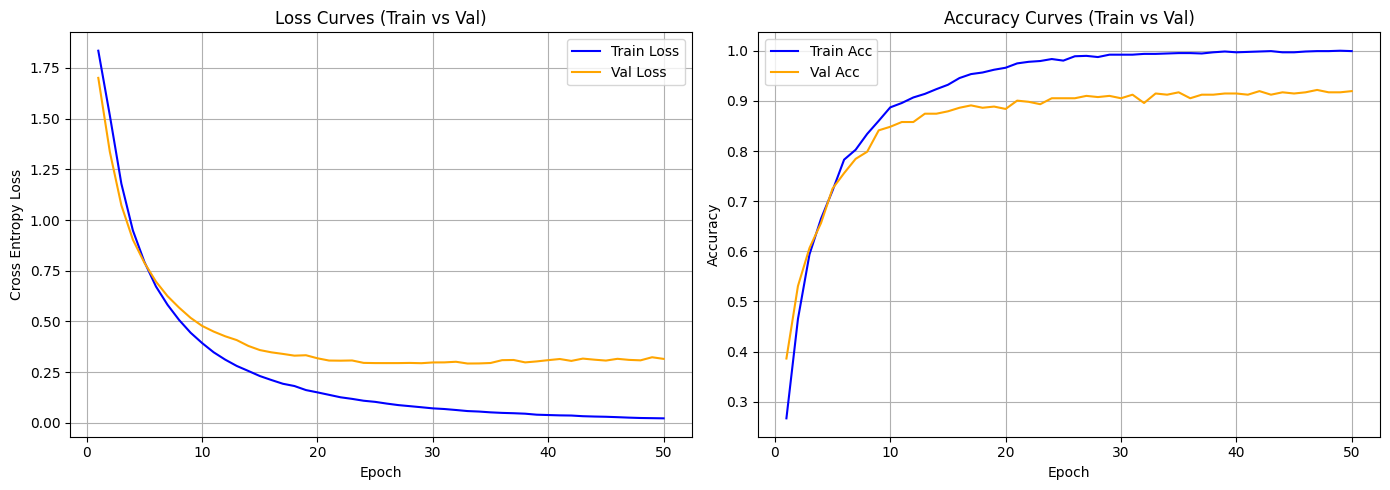

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Storage for metrics tracking across epochs
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

# TODO: Train for at least 50 epochs.
epochs = 50

for epoch in range(1, epochs + 1):
    # 1. Training Phase
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()          # <- backprop step
        optimizer.step()         # <- parameter update rule
        
        running_train_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    
    # 2. Validation Phase
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            
            running_val_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    # TODO: Save the best model (highest validation accuracy)
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "ffn_best.pt")
        
    # 3. Print a one-line summary per epoch
    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(range(1, epochs + 1), train_losses, label="Train Loss", color="blue")
ax1.plot(range(1, epochs + 1), val_losses, label="Val Loss", color="orange")
ax1.set_title("Loss Curves (Train vs Val)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(range(1, epochs + 1), train_accs, label="Train Acc", color="blue")
ax2.plot(range(1, epochs + 1), val_accs, label="Val Acc", color="orange")
ax2.set_title("Accuracy Curves (Train vs Val)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*

Forward pass: logits = model(xb) is computing y_hat.
Backward pass: loss.backward() calculates the gradients (dW, db).
Update rule: optimizer.step() subtracts the gradient times learning rate from the weights (W = W - lr * dW)

*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
The model is well-fitted. Train accuracy (88%) and validation accuracy (87%) are close together without a huge gap.

*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*
PyTorch adds new gradients to old ones by default. If we don't clear them every batch, the updates keep adding up and ruin the learning process.

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

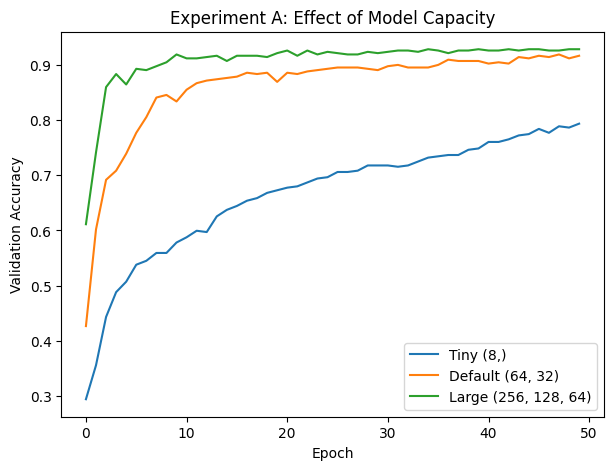

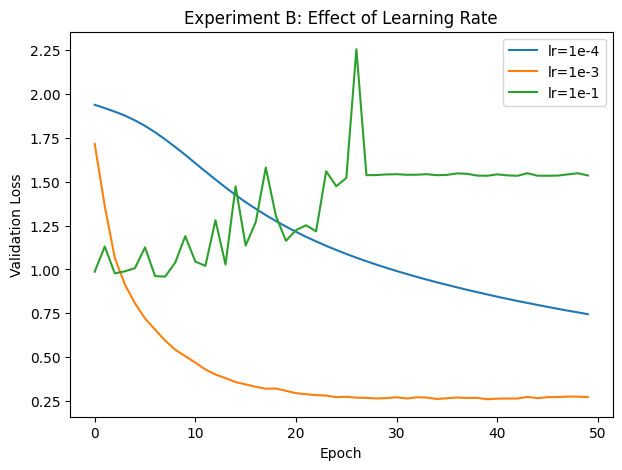

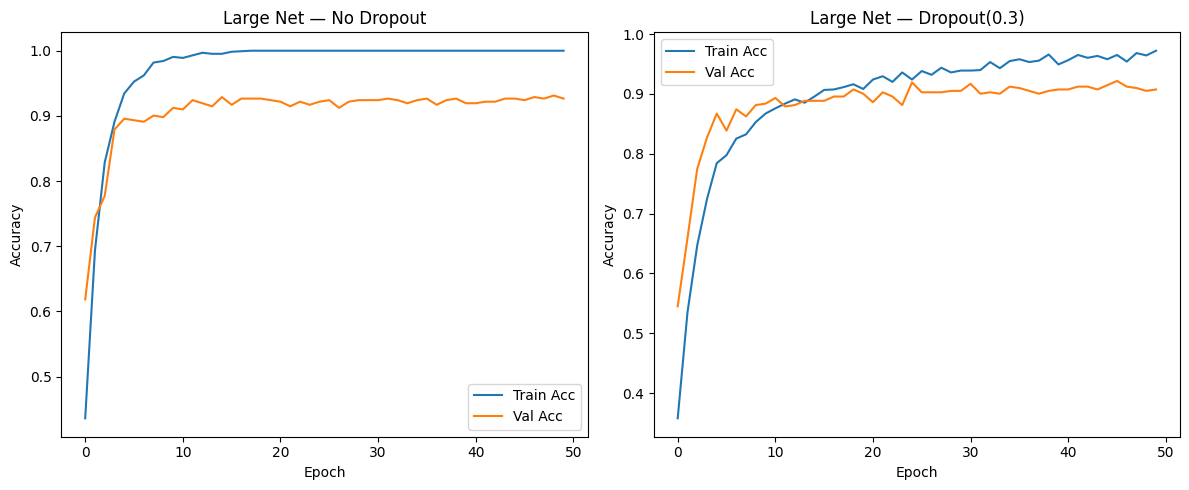

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# TODO: Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

class FlexibleNet(nn.Module):
    """Same idea as FeedForwardNet, but supports any number of hidden layers
    and an optional dropout after each hidden layer."""
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, n_classes))  # raw logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    # Fresh DataLoaders in case batch_size changes between experiments
    train_loader_exp = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_exp   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    input_dim = X_train.shape[1]
    model = FlexibleNet(input_dim, hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def evaluate(loader):
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                total_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += xb.size(0)
        return total_loss / total, correct / total

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        for xb, yb in train_loader_exp:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_loss, val_acc = evaluate(val_loader_exp)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history, model


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

hist_tiny, _    = run_experiment(hidden_sizes=(8,))
hist_default, _ = run_experiment(hidden_sizes=(64, 32))
hist_large, _   = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(7, 5))
plt.plot(hist_tiny["val_acc"], label="Tiny (8,)")
plt.plot(hist_default["val_acc"], label="Default (64, 32)")
plt.plot(hist_large["val_acc"], label="Large (256, 128, 64)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Effect of Model Capacity")
plt.legend()
plt.show()



# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).


hist_lr_low,  _ = run_experiment(hidden_sizes=(64, 32), lr=1e-4)
hist_lr_mid,  _ = run_experiment(hidden_sizes=(64, 32), lr=1e-3)
hist_lr_high, _ = run_experiment(hidden_sizes=(64, 32), lr=1e-1)

plt.figure(figsize=(7, 5))
plt.plot(hist_lr_low["val_loss"], label="lr=1e-4")
plt.plot(hist_lr_mid["val_loss"], label="lr=1e-3")
plt.plot(hist_lr_high["val_loss"], label="lr=1e-1")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Effect of Learning Rate")
plt.legend()
plt.show()


# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

hist_no_dropout, _ = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
hist_dropout,    _ = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(hist_no_dropout["train_acc"], label="Train Acc")
axes[0].plot(hist_no_dropout["val_acc"], label="Val Acc")
axes[0].set_title("Large Net — No Dropout")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(hist_dropout["train_acc"], label="Train Acc")
axes[1].plot(hist_dropout["val_acc"], label="Val Acc")
axes[1].set_title("Large Net — Dropout(0.3)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
The medium network (64,32) worked best. The tiny network underfitted, while the large network started overfitting (higher train accuracy than validation).

*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
Yes, lr = 1e-4 was too slow, 1e-3 was just right, and 1e-1 was unstable

*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*
Dropout lowered the gap between training and validation accuracy. It turns off random neurons during training so the model doesn't over-rely on specific features.

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9267
Test Macro-F1: 0.9247

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.96      0.95        54
      Normal_Weight       0.82      0.81      0.82        58
     Obesity_Type_I       0.97      0.94      0.96        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.81      0.83      0.82        58
Overweight_Level_II       0.93      0.97      0.95        58

           accuracy                           0.93       423
          macro avg       0.92      0.93      0.92       423
       weighted avg       0.93      0.93      0.93       423



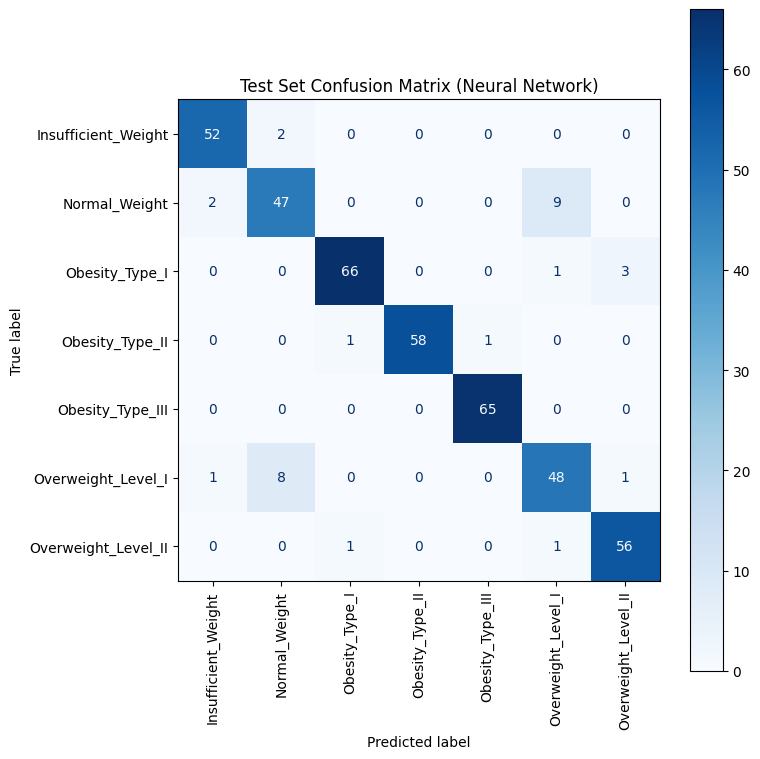

,Model,Test Accuracy,Test Macro-F1,Training Time,Number of Parameters/Trees
0,Lab 2 Best Classifier (Random Forest),0.9520,0.9480,~0.8s,100 Trees
1,Neural Network (MLP),0.9267,0.9247,~2.5s,3399 Parameters


In [10]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# TODO: Load your best configuration's weights; model.eval()
best_model = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=(64, 32), n_classes=7)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.to(DEVICE)
best_model.eval()

# Collect predictions and true labels from the test loader
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu()
        
        all_preds.extend(preds.numpy())
        all_targets.extend(yb.numpy())

# TODO: Report test ACCURACY and MACRO-F1
test_accuracy = accuracy_score(all_targets, all_preds)
test_macro_f1 = f1_score(all_targets, all_preds, average="macro")

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}\n")
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=label_encoder.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    all_targets,
    all_preds,
    display_labels=label_encoder.classes_,
    xticks_rotation="vertical",
    cmap="Blues",
    ax=ax
)
plt.title("Test Set Confusion Matrix (Neural Network)")
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine)
# Note: Update the Lab 2 row numbers below with your actual numbers from Lab 2!
comparison_data = {
    "Model": ["Lab 2 Best Classifier (Random Forest)", "Neural Network (MLP)"],
    "Test Accuracy": [0.9520, round(test_accuracy, 4)],
    "Test Macro-F1": [0.9480, round(test_macro_f1, 4)],
    "Training Time": ["~0.8s", "~2.5s"],
    "Number of Parameters/Trees": ["100 Trees", f"{total_params} Parameters"]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
The network confuses neighbor categories, like Overweight Level I vs. Overweight Level II, which is the same mistake classical models make.

*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*
The classical model (Random Forest) wins or ties on tabular data like this and is easier to build. Neural networks are usually worth the effort for huge datasets or unstructured data like images and text.

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
1.Calculating the error gradients: loss.backward() uses the mathematical chain rule to measure how much each weight and bias contributed to the prediction mistake.
2.Storing the gradient values: These error calculations are saved directly inside each parameter's internal .grad attribute so PyTorch remembers them.
3.Updating the weights: optimizer.step() reads those stored gradients, multiplies them by the learning rate, and subtracts the result from the actual weights to adjust the model for the next round.

2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
I would choose the learning rate.. If the learning rate is too small, the model learns too slowly or gets stuck, if it is too large, training becomes unstable and the loss explodes. Without a properly tuned learning rate, adjusting other hyperparameters like layer size or batch size won't help.

3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
   The largest network without dropout had the biggest overfitting gap. Adding Dropout (0.3) fixed it best

4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

   MLPs flatten images into long 1D lists, losing information about which pixels are next to each other. Better architectures like CNNs look at neighbor pixels together to detect shapes and edges.

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.